In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
file_path = '/content/drive/MyDrive/HousingData.csv'
try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print(f"Error: Could not find {file_path}. Please check the file name and path.")

# Display basic information
display(df.head())
display(df.info())
try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print(f"Error: Could not find {file_path}. Please check the file name and path.")

# Display basic information
display(df.head())
display(df.info())

Dataset loaded successfully!


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


None

Dataset loaded successfully!


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


None

In [8]:
#DATA PREPROCESSING
# A. Handle Missing Values
missing_values = df.isnull().sum().sum()
if missing_values > 0:
    print(f"Found {missing_values} missing values. Filling with column medians...")
    df = df.fillna(df.median())
else:
    print("No missing values found.")
#B. Handle Outliers using the IQR Technique
def remove_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Filter out the outliers
    df_filtered = dataframe[(dataframe[column] >= lower_limit) & (dataframe[column] <= upper_limit)]
    print(f"Removed {len(dataframe) - len(df_filtered)} outliers based on {column}.")
    return df_filtered

df_cleaned = remove_outliers_iqr(df, 'MEDV')


--- Data Preprocessing ---
No missing values found.
Removed 40 outliers based on MEDV.


In [9]:
# DATA SPLITTING
X = df_cleaned.drop(columns=['MEDV'])
y = df_cleaned['MEDV']

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")


Training data shape: (372, 13)
Testing data shape: (94, 13)


In [10]:
# MODEL SELECTION AND TRAINING
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

print("\n--- Model Evaluation ---")
best_model_name = ""
best_r2_score = -np.inf
best_model = None
for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"{name}:")
    print(f"  MSE: {mse:.2f}")
    print(f"  R-squared (R2): {r2:.2f}")

    # Track the best model
    if r2 > best_r2_score:
        best_r2_score = r2
        best_model_name = name
        best_model = model

print(f"\nBest Base Model: {best_model_name} with an R2 Score of {best_r2_score:.2f}")


--- Model Evaluation ---
Linear Regression:
  MSE: 10.39
  R-squared (R2): 0.74
Decision Tree:
  MSE: 14.78
  R-squared (R2): 0.63
Gradient Boosting:
  MSE: 6.00
  R-squared (R2): 0.85

Best Base Model: Gradient Boosting with an R2 Score of 0.85


In [15]:
# FINE TUNING - THE BEST MODEL
if best_model_name == "Gradient Boosting":
    param_grid = {
        'n_estimators': [50, 100, 150],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 4, 5]
    }

    print("Performing Grid Search for Gradient Boosting...")
    grid_search = GridSearchCV(estimator=GradientBoostingRegressor(random_state=42),
                               param_grid=param_grid,
                               cv=3,
                               scoring='r2',
                               n_jobs=-1)

    grid_search.fit(X_train, y_train)

    final_model = grid_search.best_estimator_
    print(f"Best Parameters: {grid_search.best_params_}")

    # Evaluate the fine-tuned model
    y_pred_tuned = final_model.predict(X_test)
    tuned_mse = mean_squared_error(y_test, y_pred_tuned)
    tuned_r2 = r2_score(y_test, y_pred_tuned)

    print(f"Fine-Tuned MSE: {tuned_mse:.2f}")
    print(f"Fine-Tuned R-squared (R2): {tuned_r2:.2f}")

else:
    print(f"Fine-tuning is currently configured for Gradient Boosting. Proceeding with the base {best_model_name}.")
    final_model = best_model

Performing Grid Search for Gradient Boosting...
Best Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}
Fine-Tuned MSE: 6.41
Fine-Tuned R-squared (R2): 0.84


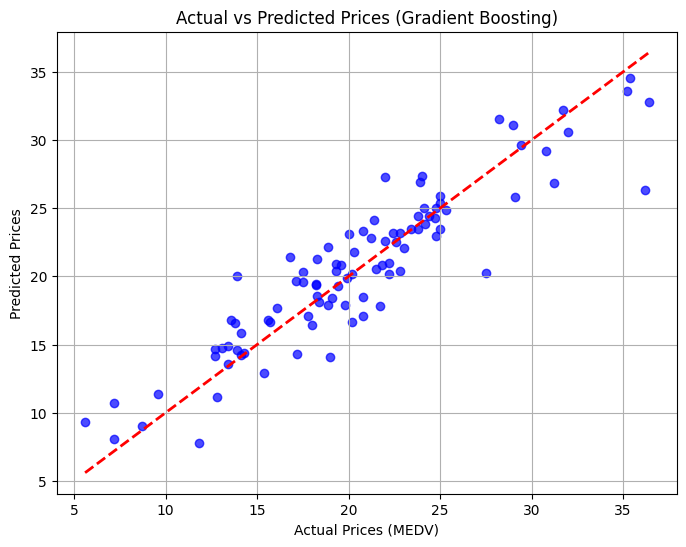

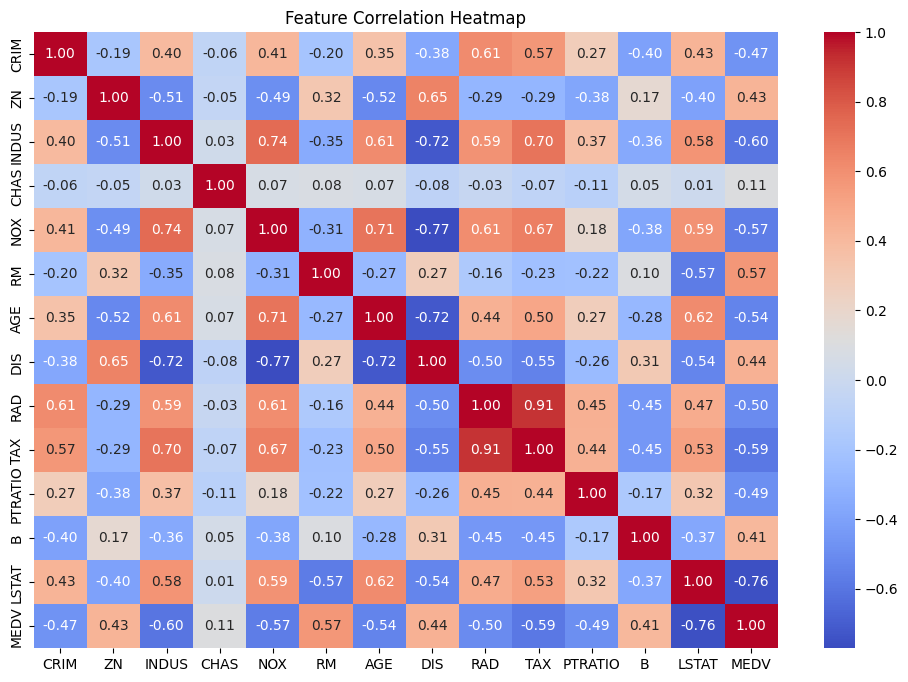

In [21]:
# VISUALIZING - ACTUAL VS PREDICTED
plt.figure(figsize=(8, 6))
plt.scatter(y_test, final_model.predict(X_test), alpha=0.7, color='b')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Prices (MEDV)')
plt.ylabel('Predicted Prices')
plt.title(f'Actual vs Predicted Prices ({best_model_name})')
plt.grid(True)
plt.show()
plt.figure(figsize=(12, 8))
sns.heatmap(df_cleaned.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()


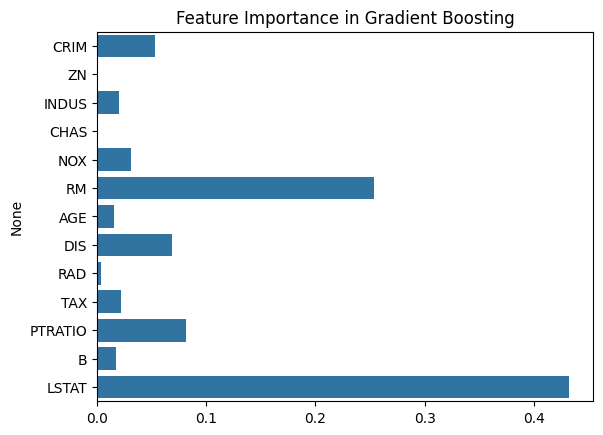

In [17]:
# IMPORTANCE
importance = final_model.feature_importances_
sns.barplot(x=importance, y=X.columns)
plt.title("Feature Importance in Gradient Boosting")
plt.show()